<a href="https://colab.research.google.com/github/parviza9999/InterviewN/blob/main/pytorch_intro_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

To implement your MNIST inference workflow using the Functional/Subclassing style, you need to structure your code so that the model logic is encapsulated in a class. This is the professional, modular approach favored in research and production.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Data Preparation
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)

# 3. Model Definition
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 13 * 13, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = MNIST_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Training Loop
model.train()
print(f"Training on: {device}")

for epoch in range(2): # Number of epochs
    for batch_idx, (data, target) in enumerate(trainloader):
        data, target = data.to(device), target.to(device)

        # Core Training Steps
        optimizer.zero_grad()       # 1. Clear gradients
        output = model(data)        # 2. Forward pass
        loss = criterion(output, target) # 3. Calculate loss
        loss.backward()             # 4. Backward pass
        optimizer.step()            # 5. Update weights

        if batch_idx % 200 == 0:
            print(f"Epoch {epoch+1} | Batch {batch_idx} | Loss: {loss.item():.4f}")

print("Training finished.")

100%|██████████| 9.91M/9.91M [00:00<00:00, 136MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 17.5MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 39.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.44MB/s]


Training on: cpu
Epoch 1 | Batch 0 | Loss: 2.3286
Epoch 1 | Batch 200 | Loss: 0.1447
Epoch 1 | Batch 400 | Loss: 0.1793
Epoch 1 | Batch 600 | Loss: 0.1089
Epoch 1 | Batch 800 | Loss: 0.0290
Epoch 2 | Batch 0 | Loss: 0.0318
Epoch 2 | Batch 200 | Loss: 0.1016
Epoch 2 | Batch 400 | Loss: 0.0789
Epoch 2 | Batch 600 | Loss: 0.0267
Epoch 2 | Batch 800 | Loss: 0.0947
Training finished.


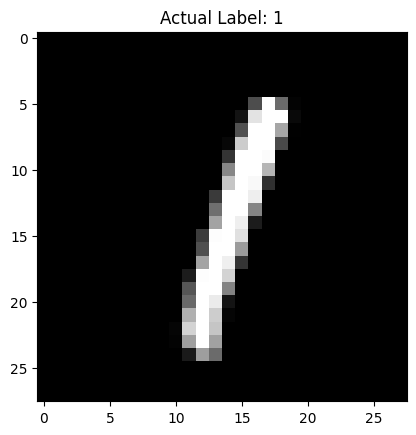

Predicted label: 1


In [ ]:
import matplotlib.pyplot as plt
testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 1. Get image and label from the dataset
image_tensor, label = testset[5]

# 2. Visualize
plt.imshow(image_tensor.squeeze(), cmap='gray')
plt.title(f"Actual Label: {label}")
plt.show()

# 3. Inference
model.eval() # Important: Sets mode to evaluation
with torch.no_grad(): # Disable gradient tracking
    # Add batch dimension: (C, H, W) -> (1, C, H, W)
    img_batch = image_tensor.unsqueeze(0).to(device)

    # Pass through the model
    output = model(img_batch)

    # Get probabilities and prediction
    probabilities = F.softmax(output, dim=1)
    predicted_label = torch.argmax(probabilities, dim=1)

print(f"Predicted label: {predicted_label.item()}")